In [ ]:
# 10.2. Муравьиная система (Ant System)

Реализация алгоритма оптимизации муравьиной системы для задачи коммивояжёра (TSP).

**Параметры по умолчанию (Dorigo et al., 1996):**
- `N = n` — число муравьёв = числу городов
- `α = 1`, `β = 5` — важность феромона и эвристики
- `Q = 100` — константа выделения феромона
- `ρ ∈ [0.5, 0.99]` — скорость испарения
- `τ₀ ≈ 10⁻⁶` — начальный уровень феромона

In [1]:
using Plots
using Random
using Statistics

In [3]:
euclidean(a, b) = sqrt((a[1]-b[1])^2 + (a[2]-b[2])^2)

function distance_matrix(cities)
    n = length(cities)
    D = zeros(n, n)
    for i in 1:n, j in 1:n
        D[i,j] = i == j ? Inf : euclidean(cities[i], cities[j])
    end
    return D
end

function tour_length(tour, D)
    n = length(tour)
    return sum(D[tour[i], tour[mod1(i+1, n)]] for i in 1:n)
end

tour_length (generic function with 1 method)

In [4]:
"""
    ant_system(cities; n_ants, n_iter, α, β, ρ, Q, τ0, start_city, seed)

Решает TSP методом муравьиной системы.

# Аргументы
- `cities`      — вектор кортежей/векторов [(x1,y1), (x2,y2), ...]
- `n_ants`      — число муравьёв (по умолчанию = числу городов)
- `n_iter`      — число итераций (поколений)
- `α`           — вес феромона
- `β`           — вес эвристики (1/d)
- `ρ`           — скорость испарения феромона ∈ (0,1)
- `Q`           — константа выделения феромона
- `τ0`          — начальный уровень феромона
- `start_city`  — стартовый город (0 = случайный)
- `seed`        — зерно генератора (0 = без фиксации)
"""
function ant_system(cities;
        n_ants    = 0,
        n_iter    = 200,
        α         = 1.0,
        β         = 5.0,
        ρ         = 0.5,
        Q         = 100.0,
        τ0        = 1e-6,
        start_city = 0,
        seed       = 42)

    seed > 0 && Random.seed!(seed)

    n       = length(cities)
    n_ants  = n_ants == 0 ? n : n_ants
    D       = distance_matrix(cities)
    η       = 1.0 ./ D                 # эвристика (обратное расстояние)

    # Феромоны
    τ = fill(τ0, n, n)

    best_tour   = Int[]
    best_length = Inf
    history     = Float64[]

    for iter in 1:n_iter
        all_tours   = Vector{Vector{Int}}(undef, n_ants)
        all_lengths = zeros(n_ants)

        # Каждый муравей строит маршрут
        for k in 1:n_ants
            s = start_city == 0 ? rand(1:n) : start_city
            visited  = falses(n)
            tour     = Vector{Int}(undef, n)
            tour[1]  = s
            visited[s] = true

            for step in 2:n
                cur = tour[step-1]
                # Вероятности перехода
                weights = zeros(n)
                for j in 1:n
                    visited[j] && continue
                    weights[j] = (τ[cur,j]^α) * (η[cur,j]^β)
                end
                total = sum(weights)
                if total == 0.0
                    # если феромоны совсем малы — равномерный выбор
                    weights .= .!visited
                    total = sum(weights)
                end
                probs = weights ./ total

                # Рулеточный выбор
                r   = rand()
                cum = 0.0
                next = 0
                for j in 1:n
                    cum += probs[j]
                    if r <= cum
                        next = j
                        break
                    end
                end
                next == 0 && (next = findfirst(.!visited))

                tour[step]    = next
                visited[next] = true
            end

            L               = tour_length(tour, D)
            all_tours[k]    = tour
            all_lengths[k]  = L

            if L < best_length
                best_length = L
                best_tour   = copy(tour)
            end
        end

        # Обновление феромонов
        τ .*= (1.0 - ρ)                # испарение

        for k in 1:n_ants
            δ = Q / all_lengths[k]
            t = all_tours[k]
            for step in 1:n
                i = t[step]
                j = t[mod1(step+1, n)]
                τ[i,j] += δ
                τ[j,i] += δ            # симметричная TSP
            end
        end

        push!(history, best_length)
    end

    return best_tour, best_length, history
end

ant_system

## Вспомогательная функция: визуализация маршрута

In [6]:
"""
    plot_result(cities, tour, history; title)

Рисует маршрут и кривую сходимости.
"""
function plot_result(cities, tour, history; title="Муравьиная система — TSP")
    xs = [c[1] for c in cities]
    ys = [c[2] for c in cities]
    n  = length(tour)

    # Координаты маршрута (замкнутый цикл)
    tx = [cities[tour[i]][1] for i in 1:n]
    ty = [cities[tour[i]][2] for i in 1:n]
    push!(tx, tx[1]); push!(ty, ty[1])

    start_idx = tour[1]

    p1 = plot(tx, ty,
        lw=2, color=:steelblue, label="Маршрут",
        title=title,
        xlabel="X", ylabel="Y",
        legend=:topright, size=(600,500))

    scatter!(p1, xs, ys,
        color=:orangered, ms=7, label="Города")

    # Стартовый город — особый маркер
    scatter!(p1, [cities[start_idx][1]], [cities[start_idx][2]],
        color=:green, ms=10, marker=:star5, label="Старт")

    # Подписи городов
    for (i, c) in enumerate(cities)
        annotate!(p1, c[1], c[2]+0.015*(maximum(ys)-minimum(ys)),
            text(string(i), 8, :center, :black))
    end

    p2 = plot(history,
        lw=2, color=:darkorange,
        xlabel="Итерация", ylabel="Длина лучшего пути",
        title="Сходимость", legend=false)

    plot(p1, p2, layout=(1,2), size=(1100, 480))
end


plot_result

## Тест 1: Случайные точки

In [7]:
using Printf

Random.seed!(7)
N_CITIES = 15

random_cities = [(rand(), rand()) for _ in 1:N_CITIES]

start = rand(1:N_CITIES)
println("Стартовый город: $start")
println("Города:")
for (i, c) in enumerate(random_cities)
    @printf("  %2d: (%.3f, %.3f)\n", i, c[1], c[2])
end

Стартовый город: 9
Города:
   1: (0.244, 0.719)
   2: (0.811, 0.466)
   3: (0.943, 0.064)
   4: (0.880, 0.845)
   5: (0.368, 0.212)
   6: (0.833, 0.688)
   7: (0.861, 0.653)
   8: (0.746, 0.946)
   9: (0.790, 0.944)
  10: (0.786, 0.312)
  11: (0.307, 0.991)
  12: (0.596, 0.988)
  13: (0.129, 0.144)
  14: (0.163, 0.671)
  15: (0.305, 0.064)


Лучший маршрут: 9 → 8 → 12 → 11 → 1 → 14 → 13 → 15 → 5 → 3 → 10 → 2 → 7 → 6 → 4
Длина маршрута: 3.3247


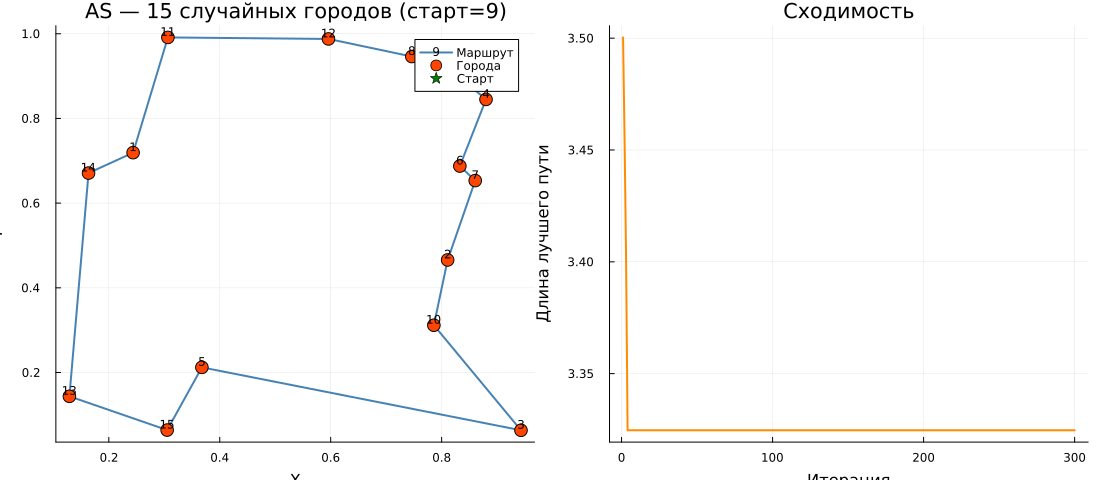

In [8]:
# Запуск муравьиной системы на случайных городах
tour1, len1, hist1 = ant_system(random_cities;
    n_iter     = 300,
    α          = 1.0,
    β          = 5.0,
    ρ          = 0.5,
    Q          = 100.0,
    τ0         = 1e-6,
    start_city = start,
    seed       = 0)

@printf("Лучший маршрут: %s\n", join(tour1, " → "))
@printf("Длина маршрута: %.4f\n", len1)

plot_result(random_cities, tour1, hist1;
    title="AS — $N_CITIES случайных городов (старт=$start)")

## Тест 2: Собственный набор точек

In [ ]:
custom_cities = [
    (0.0, 0.0),  
    (1.0, 0.0), 
    (2.0, 0.5),  
    (2.5, 1.5),   
    (2.0, 2.5),  
    (1.0, 3.0),  
    (0.0, 2.5),  
    (-0.5, 1.5),  
    (0.5, 1.5),   
    (1.5, 1.0),   
]

custom_start = 1   # стартовый город (1-based), 0 = случайный

println("Пользовательские города ($(length(custom_cities)) шт.):")
for (i, c) in enumerate(custom_cities)
    @printf("  %2d: (%.2f, %.2f)\n", i, c[1], c[2])
end

In [ ]:
# Запуск на пользовательских точках
tour2, len2, hist2 = ant_system(custom_cities;
    n_iter     = 400,
    α          = 1.0,
    β          = 5.0,
    ρ          = 0.6,
    Q          = 100.0,
    τ0         = 1e-6,
    start_city = custom_start,
    seed       = 42)

@printf("Лучший маршрут: %s\n", join(tour2, " → "))
@printf("Длина маршрута: %.4f\n", len2)

plot_result(custom_cities, tour2, hist2;
    title="AS — пользовательские точки (старт=$custom_start)")